In [46]:
import pandas as pd
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv("Retail_Transaction_Dataset.csv")

In [48]:

print(df.shape)

(100000, 10)


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  str    
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  str    
 5   PaymentMethod       100000 non-null  str    
 6   StoreLocation       100000 non-null  str    
 7   ProductCategory     100000 non-null  str    
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), str(5)
memory usage: 7.6 MB


In [50]:
df.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,08-05-2023 00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,03-11-2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [51]:
pd.isnull(df)

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False


In [52]:
print(df.isnull().sum())

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64


In [53]:
df = df.drop_duplicates()

In [54]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],errors='coerce')

In [55]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [56]:
df['Month'] = df['TransactionDate'].dt.month

df['Year'] = df['TransactionDate'].dt.year

df['DayName'] = df['TransactionDate'].dt.day_name()

In [57]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="rahul1234",
  database="retail_analytics",
    auth_plugin='mysql_native_password'
)

print("Connected Successfully")


Connected Successfully


In [58]:
cursor = conn.cursor()

In [59]:
    sql = """
    INSERT INTO retail_transactions
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """

    values = (
        int(row['CustomerID']),
        row['ProductID'],
        int(row['Quantity']),
        float(row['Price']),
        row['TransactionDate'].to_pydatetime(),
        row['PaymentMethod'],
        row['StoreLocation'],
        row['ProductCategory'],
        float(row['DiscountApplied(%)']),
        float(row['TotalAmount']),
        int(row['Month']),
        int(row['Year']),
        row['DayName']
    )

In [60]:

    cursor.execute(sql, values)

In [61]:
conn.commit()

print("Data inserted successfully")

Data inserted successfully


In [71]:

# data visualization
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
df = pd.read_csv("Retail_Transaction_Dataset.csv")

In [73]:
#monthly sales
monthly_sales = df.groupby('ProductCategory')['TotalAmount'].sum()

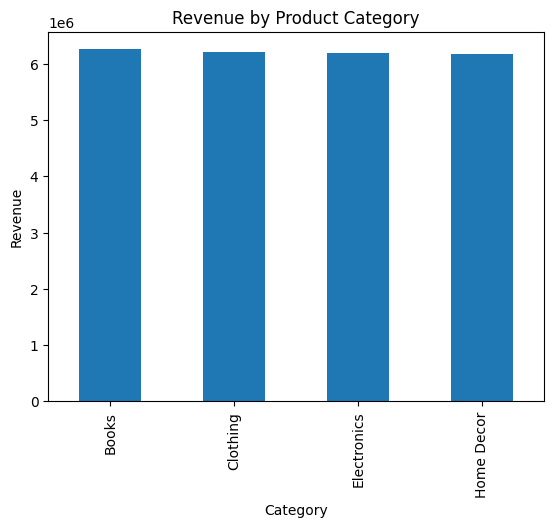

In [74]:
monthly_sales.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [78]:
#customer segmentation
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [79]:
df = pd.read_csv("Retail_Transaction_Dataset.csv")

In [80]:
customer_data = df.groupby('CustomerID').agg({
    'TotalAmount':'sum',
    'Quantity':'sum'
}).reset_index()

In [81]:

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    customer_data[['TotalAmount','Quantity']]
)

In [82]:
kmeans = KMeans(n_clusters=4, random_state=42)

customer_data['Cluster'] = kmeans.fit_predict(scaled_data)

print(customer_data.head())

   CustomerID  TotalAmount  Quantity  Cluster
0          14   256.232791         5        3
1          42   502.656523         7        1
2          49    21.399047         1        0
3          59   249.492696        12        3
4          65   548.006625         8        1


In [83]:
customer_data.to_csv("customer_segments.csv", index=False)

In [3]:
print("Final report exported successfully")

Final report exported successfully
